In [124]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sklearn as sk
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.preprocessing import StandardScaler

In [125]:
df = pd.read_csv('SouthGermanCredit.asc', delimiter=' ')
df.head()

,laufkont,laufzeit,moral,verw,hoehe,sparkont,beszeit,rate,famges,buerge,...,verm,alter,weitkred,wohn,bishkred,beruf,pers,telef,gastarb,kredit
0,1,18,4,2,1049,1,2,4,2,1,...,2,21,3,1,1,3,2,1,2,1
1,1,9,4,0,2799,1,3,2,3,1,...,1,36,3,1,2,3,1,1,2,1
2,2,12,2,9,841,2,4,2,2,1,...,1,23,3,1,1,2,2,1,2,1
3,1,12,4,0,2122,1,3,3,3,1,...,1,39,3,1,2,2,1,1,1,1
4,1,12,4,0,2171,1,3,4,3,1,...,2,38,1,2,2,2,2,1,1,1


In [126]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

In [127]:
pca = PCA()
pca.fit(X_scaled)

cum_variance = np.cumsum(pca.explained_variance_ratio_)
print(cum_variance)

[0.12157518 0.22405317 0.29484822 0.35868189 0.41723995 0.47464063
 0.52915295 0.58097909 0.62865795 0.67239425 0.71403442 0.75299657
 0.79048894 0.82667955 0.85982615 0.89017122 0.91760072 0.94282384
 0.96555456 0.98762585 1.        ]


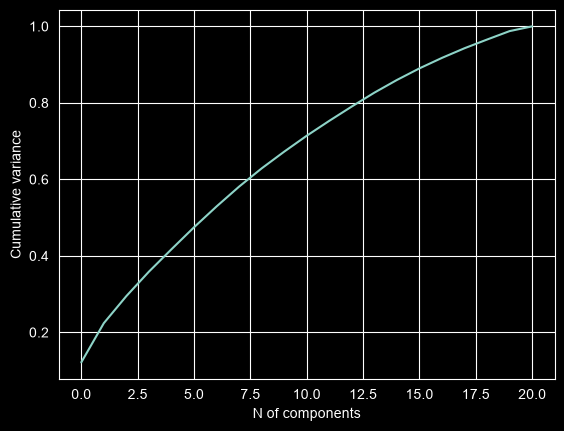

In [128]:
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('N of components')
plt.ylabel('Cumulative variance')
plt.show()

In [129]:
variance = 0.70
n_of_components = np.argmax(cum_variance >= variance) + 1
print(n_of_components)

11


In [130]:
X_reduced = PCA(n_components=n_of_components).fit_transform(X_scaled)

In [131]:
clusters = range(2, 11)

kmeans_scores = []

for cluster in clusters:
    km = KMeans(n_clusters=cluster, random_state=42, n_init=10)
    km_test = km.fit_predict(X_reduced)
    kmeans_scores.append(silhouette_score(X_reduced, km_test))

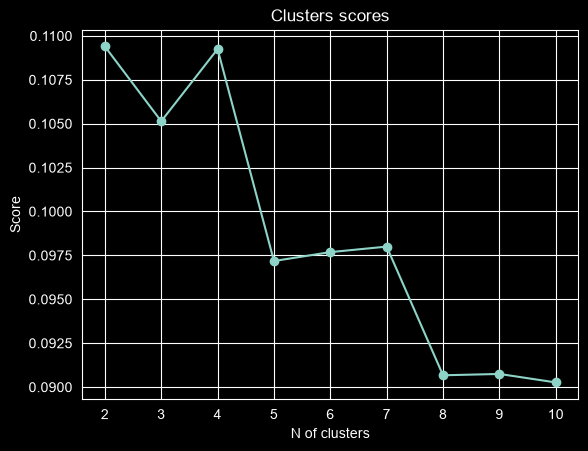

In [132]:
plt.xlabel('N of clusters')
plt.plot(clusters, kmeans_scores, marker='o', label='k-means')
plt.ylabel('Score')
plt.title('Clusters scores')
plt.show()

# 5 clusters

In [133]:
best_clusters_n = 5

labels_full = KMeans(n_clusters=best_clusters_n, random_state=42, n_init=10).fit_predict(X_scaled)
labels_reduced = KMeans(n_clusters=best_clusters_n, random_state=42, n_init=10).fit_predict(X_reduced)

score = adjusted_rand_score(labels_full, labels_reduced)
print(score)

0.36834017628516763
